In [3]:
# csv files
import pandas as pd
# Read the data
df_train=pd.read_csv('../data_ingestion/data_csvs/train.csv')
df_localizers=pd.read_csv('../data_ingestion/data_csvs/train_localizers.csv')

### df_train is the main info of the labled classes

In [6]:
train_cols=df_train.columns

In [11]:
print(f"==Columns in train dataset==")
for col in train_cols:
    print(f'{col}------{df_train[col].dtype}')

==Columns in train dataset==
SeriesInstanceUID------object
PatientAge------int64
PatientSex------object
Modality------object
Left Infraclinoid Internal Carotid Artery------int64
Right Infraclinoid Internal Carotid Artery------int64
Left Supraclinoid Internal Carotid Artery------int64
Right Supraclinoid Internal Carotid Artery------int64
Left Middle Cerebral Artery------int64
Right Middle Cerebral Artery------int64
Anterior Communicating Artery------int64
Left Anterior Cerebral Artery------int64
Right Anterior Cerebral Artery------int64
Left Posterior Communicating Artery------int64
Right Posterior Communicating Artery------int64
Basilar Tip------int64
Other Posterior Circulation------int64
Aneurysm Present------int64


In [13]:
print(f"Length of dataset: {len(df_train)}")

Length of dataset: 4405


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [ ]:
# required transforms
# 1. Patient age --> 1.4 power
# 2. Gender to --> numerical
# 3. Modality --> numerical
# 4. Series remove while training

Text(0.5, 1.0, 'Age QQ Plot')

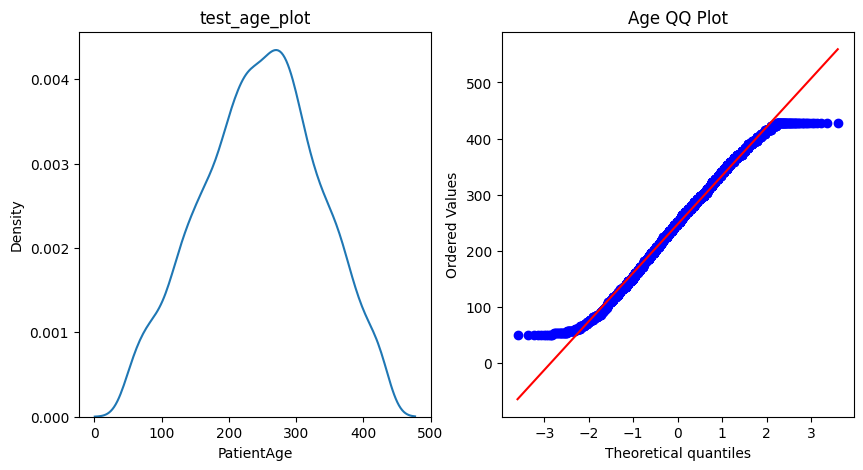

In [ ]:
degree=1.4
plt.figure(figsize=(10,5))
test_age=(df_train['PatientAge'])**degree

plt.subplot(1,2,1)
sns.kdeplot((test_age))
plt.title('test_age_plot')

plt.subplot(1,2,2)
stats.probplot(test_age, dist="norm", plot=plt)
plt.title('Age QQ Plot')

Text(0.5, 1.0, 'Age distribution')

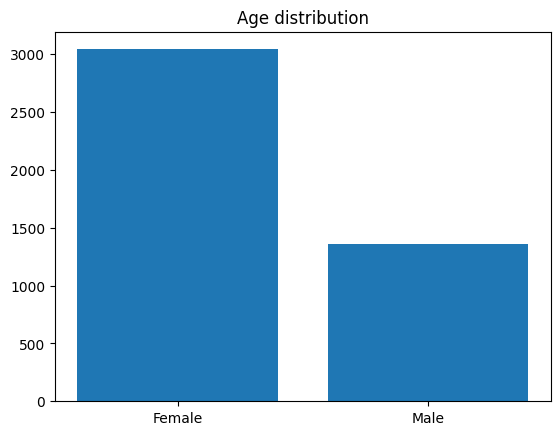

In [68]:
patient_age=df_train['PatientSex'].value_counts()
plt.bar(patient_age.index,patient_age)
plt.title('Age distribution')

Text(0.5, 1.0, 'Modality')

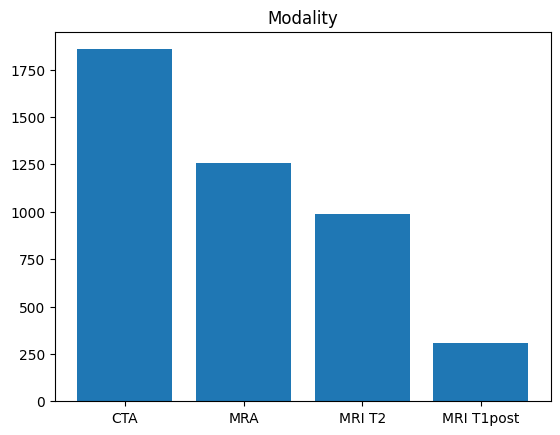

In [72]:
# modality
modality=df_train['Modality'].value_counts()
plt.bar(modality.index,modality,)
plt.title('Modality')

In [ ]:
# Modality vs anuerysm
df_train.groupby(['Modality', 'Aneurysm Present']).size().unstack(fill_value=0)

Aneurysm Present,0,1
Modality,,
CTA,860,997
MRA,699,557
MRI T1post,228,78
MRI T2,725,261


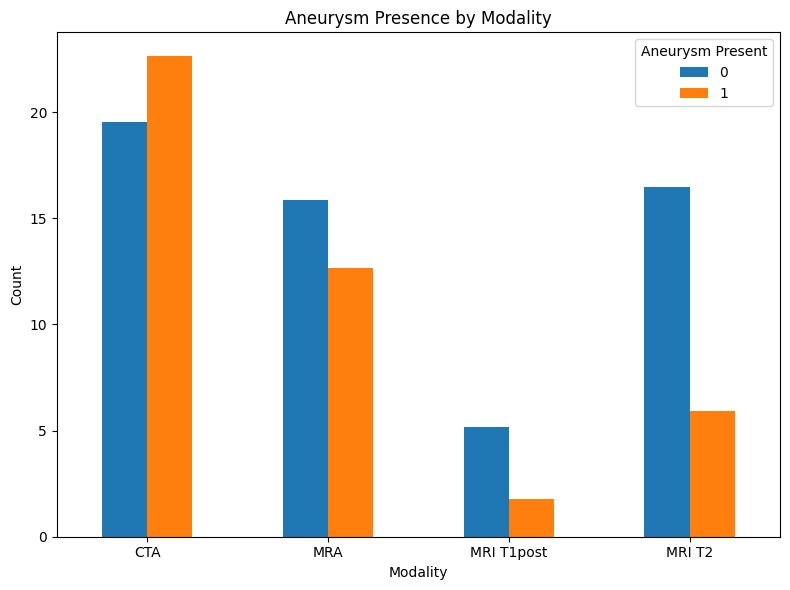

In [119]:
# Sample aggregation
df_counts = df_train.groupby(['Modality', 'Aneurysm Present']).size().unstack(fill_value=0)
df_counts=(df_counts/len(df_train))*100
# Plot
df_counts.plot(kind='bar', figsize=(8,6))
plt.title('Aneurysm Presence by Modality')
plt.xlabel('Modality')
plt.ylabel('Count')
plt.legend(title='Aneurysm Present')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [120]:
df_train.columns

Index(['SeriesInstanceUID', 'PatientAge', 'PatientSex', 'Modality',
       'Left Infraclinoid Internal Carotid Artery',
       'Right Infraclinoid Internal Carotid Artery',
       'Left Supraclinoid Internal Carotid Artery',
       'Right Supraclinoid Internal Carotid Artery',
       'Left Middle Cerebral Artery', 'Right Middle Cerebral Artery',
       'Anterior Communicating Artery', 'Left Anterior Cerebral Artery',
       'Right Anterior Cerebral Artery', 'Left Posterior Communicating Artery',
       'Right Posterior Communicating Artery', 'Basilar Tip',
       'Other Posterior Circulation', 'Aneurysm Present'],
      dtype='object')

In [121]:
# region analysis
regions=df_train.columns[4:-1]

In [124]:
df_train[regions[0]].value_counts()[0]

np.int64(4326)

In [131]:
region_dict = {'region': [], 'Present': [], 'Absent': []}
for region in regions:
    region_count = df_train[region].value_counts()
    present = region_count[0]
    absent = region_count[1]
    region_dict['region'].append(region)
    region_dict['Present'].append(present)
    region_dict['Absent'].append(absent)

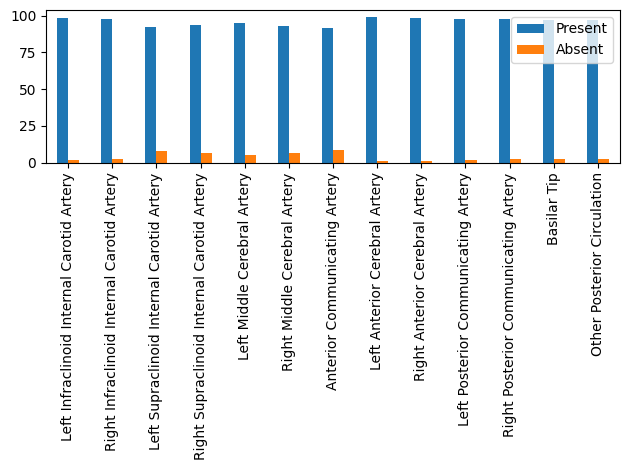

In [140]:
region_df=pd.DataFrame(region_dict)
region_df[['Present', 'Absent']] = (region_df[['Present', 'Absent']] / len(df_train)) * 100
ax = region_df.plot(kind='bar')
plt.xticks(ticks=range(len(region_df['region'])), labels=region_df['region'], rotation=90)
plt.tight_layout()

In [141]:
region_df

,region,Present,Absent
0,Left Infraclinoid Internal Carotid Artery,98.206583,1.793417
1,Right Infraclinoid Internal Carotid Artery,97.752554,2.247446
2,Left Supraclinoid Internal Carotid Artery,92.281498,7.718502
3,Right Supraclinoid Internal Carotid Artery,93.598184,6.401816
4,Left Middle Cerebral Artery,95.005675,4.994325
5,Right Middle Cerebral Artery,93.212259,6.787741
6,Anterior Communicating Artery,91.691260,8.308740
7,Left Anterior Cerebral Artery,98.955732,1.044268
8,Right Anterior Cerebral Artery,98.728717,1.271283
9,Left Posterior Communicating Artery,98.024972,1.975028


In [144]:
df_train['Aneurysm Present'].value_counts()
# Therefore although anuerysm is present 50 % overall still region percentages are higher indicating that while a presence of anuerysm is there , it is multi regional

Aneurysm Present
0    2512
1    1893
Name: count, dtype: int64

In [142]:
df_localizers.columns

Index(['SeriesInstanceUID', 'SOPInstanceUID', 'coordinates', 'location'], dtype='object')

In [2]:
import os
os.listdir()

['colab_scripts', 'data_viz.ipynb', 'samples']

In [10]:
print(os.listdir('samples/segmentations'))

['1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381.nii', '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381_cowseg.nii']


2692.0
Segmentation shape: (512, 512, 228)


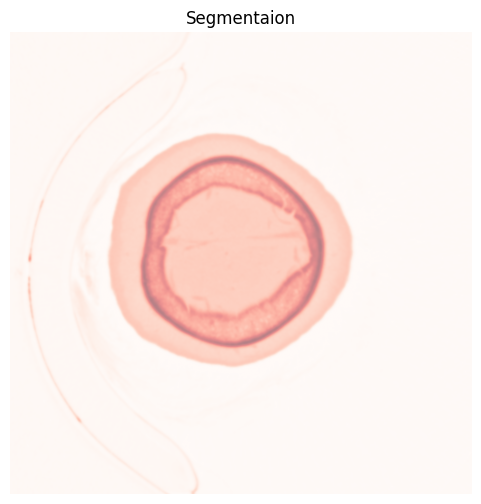

In [63]:
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np
# Some series id may not have segmentations
seg_id = '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381'
seg_path = os.path.join('./samples/segmentations', f'{seg_id}.nii')
cow_seg_path=os.path.join('./samples/segmentations', f'{seg_id}_cowseg.nii')

def show_seg(seg_path,channel=114):
    # print(os.listdir('samples/segmentations'))
    if os.path.exists(seg_path):
        seg_img = nib.load(seg_path)
        seg_data = seg_img.get_fdata()
        print(np.max(seg_data))   #-- array
        print("Segmentation shape:", seg_data.shape)

        
        plt.figure(figsize=(6,6))
        plt.imshow(seg_data[:,:,channel], alpha=0.5, cmap='Reds')  
        plt.title("Segmentaion")
        plt.axis('off')
        plt.show()
    else:
        print("No segmentation available for this series.")
show_seg(seg_path=seg_path,channel=187)


====Slice-No = 0===
Unique Values: [0.]
====Slice-No = 1===
Unique Values: [0.]
====Slice-No = 2===
Unique Values: [0.]
====Slice-No = 3===
Unique Values: [0.]
====Slice-No = 4===
Unique Values: [0.]
====Slice-No = 5===
Unique Values: [0.]
====Slice-No = 6===
Unique Values: [0.]
====Slice-No = 7===
Unique Values: [0.]
====Slice-No = 8===
Unique Values: [0.]
====Slice-No = 9===
Unique Values: [0.]
====Slice-No = 10===
Unique Values: [0.]
====Slice-No = 11===
Unique Values: [0.]
====Slice-No = 12===
Unique Values: [0.]
====Slice-No = 13===
Unique Values: [0.]
====Slice-No = 14===
Unique Values: [0.]
====Slice-No = 15===
Unique Values: [0.]
====Slice-No = 16===
Unique Values: [0.]
====Slice-No = 17===
Unique Values: [0.]
====Slice-No = 18===
Unique Values: [0.]
====Slice-No = 19===
Unique Values: [0.]
====Slice-No = 20===
Unique Values: [0.]
====Slice-No = 21===
Unique Values: [0.]
====Slice-No = 22===
Unique Values: [0.]
====Slice-No = 23===
Unique Values: [0.]
====Slice-No = 24===
Uniqu

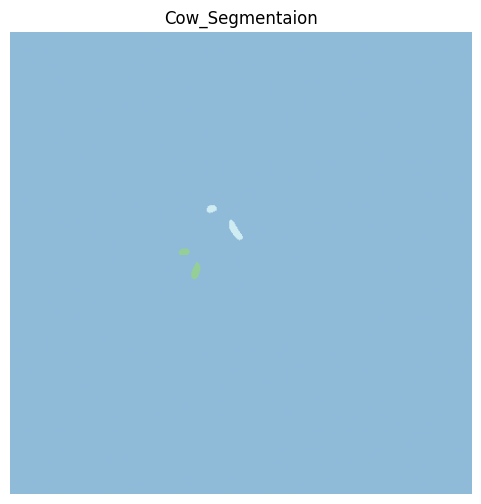

In [64]:
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np
# Some series id may not have segmentations
seg_id = '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381'

cow_seg_path=os.path.join('./samples/segmentations', f'{seg_id}_cowseg.nii')

def show_cow_seg(seg_path,channel=114):
    
    """
        Visualize the segmenation data.
        Note: 0 means background and rest 1-13 represent-
        Label Value | Label
        1-	Other Posterior Circulation
        2-	Basilar Tip
        3-	Right Posterior Communicating Artery
        4-	Left Posterior Communicating Artery
        5-	Right Infraclinoid Internal Carotid Artery
        6-	Left Infraclinoid Internal Carotid Artery
        7-	Right Supraclinoid Internal Carotid Artery
        8-	Left Supraclinoid Internal Carotid Artery
        9-	Right Middle Cerebral Artery
        10-	Left Middle Cerebral Artery
        11-	Right Anterior Cerebral Artery
        12-	Left Anterior Cerebral Artery
        13-	Anterior Communicating Artery
    """
    # print(os.listdir('samples/segmentations'))
    if os.path.exists(seg_path):
        seg_img = nib.load(seg_path)
        seg_data = seg_img.get_fdata()
        
        # print(np.max(seg_data))   #-- array operation to check array
        
        # Loop for checking relevant slices which contain anuerysm presence
        for i in range(seg_data.shape[2]):
            print(f"====Slice-No = {i}===")
            print(f"Unique Values: {np.unique(seg_data[:,:,i])}")
            
        print("Segmentation shape:", seg_data.shape)
        print(np.unique(seg_data))
        
        plt.figure(figsize=(6,6))
        plt.imshow(seg_data[:,:,channel], alpha=0.5, cmap='tab20')  
        plt.title("Cow_Segmentaion")
        plt.axis('off')
        plt.show()
    else:
        print("No segmentation available for this series.")
show_cow_seg(seg_path=cow_seg_path,channel=187)


Segmentation shape: (512, 512, 228)
COW Segmentation shape: (512, 512, 228)


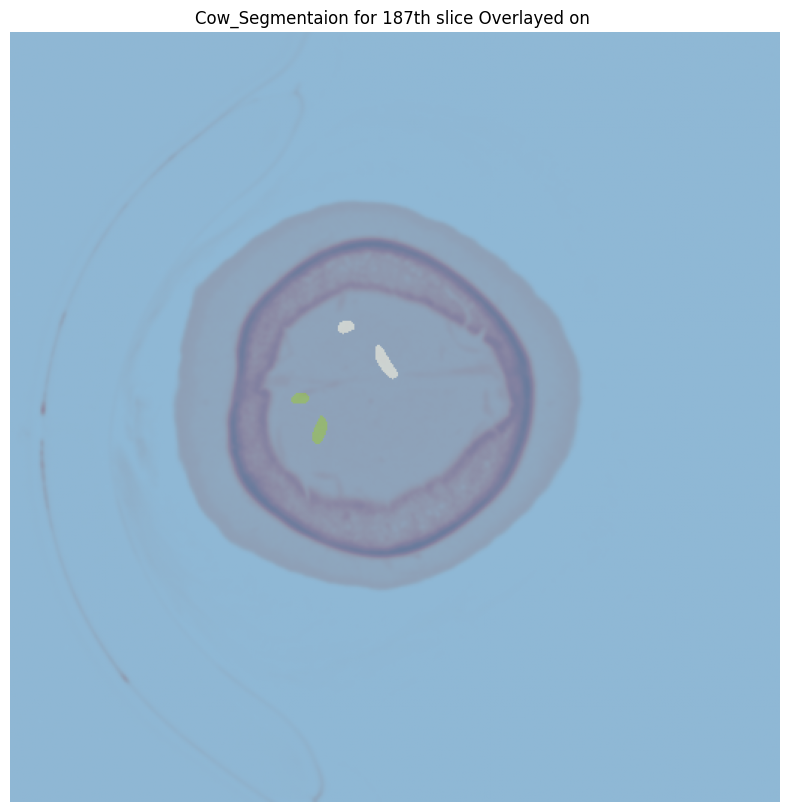

In [65]:
import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np
# Some series id may not have segmentations
seg_id = '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381'
seg_path = os.path.join('./samples/segmentations', f'{seg_id}.nii')

cow_seg_path=os.path.join('./samples/segmentations', f'{seg_id}_cowseg.nii')

def show_cow_seg_on_img(seg_path,cow_seg_path,channel=114):
    
    """
        Visualize the segmenation data.
        Note: 0 means background and rest 1-13 represent-
        Label Value | Label
        1-	Other Posterior Circulation
        2-	Basilar Tip
        3-	Right Posterior Communicating Artery
        4-	Left Posterior Communicating Artery
        5-	Right Infraclinoid Internal Carotid Artery
        6-	Left Infraclinoid Internal Carotid Artery
        7-	Right Supraclinoid Internal Carotid Artery
        8-	Left Supraclinoid Internal Carotid Artery
        9-	Right Middle Cerebral Artery
        10-	Left Middle Cerebral Artery
        11-	Right Anterior Cerebral Artery
        12-	Left Anterior Cerebral Artery
        13-	Anterior Communicating Artery
    """
    # print(os.listdir('samples/segmentations'))
    if os.path.exists(seg_path):
        seg_img = nib.load(seg_path)
        seg_data = seg_img.get_fdata()

        cow_seg_img = nib.load(cow_seg_path)
        cow_seg_data = cow_seg_img.get_fdata()
                
        ## Loop for checking relevant slices which contain anuerysm presence
        # for i in range(seg_data.shape[2]):
        #     print(f"====Slice-No = {i}===")
        #     print(f"Unique Values: {np.unique(seg_data[:,:,i])}")
            
        print("Segmentation shape:", seg_data.shape)
        print("COW Segmentation shape:", cow_seg_data.shape)
        # print(np.unique(seg_data))
        
        plt.figure(figsize=(10,10))
        plt.imshow(seg_data[:,:,channel],alpha=0.5, cmap='Reds')
        plt.imshow(cow_seg_data[:,:,channel], alpha=0.5, cmap='tab20')  
        plt.title(f"Cow_Segmentaion for {channel}th slice Overlayed on ")
        plt.axis('off')
        plt.show()
    else:
        print("No segmentation available for this series.")
show_cow_seg_on_img(seg_path=seg_path,cow_seg_path=cow_seg_path,channel=187)


In [ ]:
import plotly.graph_objects as go
seg_id = '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381'
seg_path = os.path.join('./samples/segmentations', f'{seg_id}.nii')

cow_seg_path=os.path.join('./samples/segmentations', f'{seg_id}_cowseg.nii')
def show_3d_volume(data_path, title="3D Volume", opacity=0.1):
    
    ##load 
    cow_seg_img = nib.load(data_path)
    data = cow_seg_img.get_fdata()
    
    
    
    fig = go.Figure(data=go.Volume(
        x=np.repeat(np.arange(data.shape[0]), data.shape[1]*data.shape[2]),
        y=np.tile(np.repeat(np.arange(data.shape[1]), data.shape[2]), data.shape[0]),
        z=np.tile(np.arange(data.shape[2]), data.shape[0]*data.shape[1]),
        value=data.flatten(),
        isomin=1,
        isomax=13,
        opacity=opacity, # 0-1, lower = more transparent
        surface_count=13,
        colorscale="Rainbow"
    ))
    fig.update_layout(title=title, scene=dict(aspectmode="data"))
    fig.show()

# Use cow_seg_data for vessel segmentation
show_3d_volume(cow_seg_path, title="COW Segmentation 3D")
